# Steam Recommender System Data Analysis

This notebook is used to analyze the data used in the recommender system.

# Data Load

In [1]:
import os
import glob
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, col, countDistinct, sum, when, count, lit, to_date, concat, collect_list, expr, udf, row_number, size, sqrt, avg, ntile, round as spark_round
from pyspark.ml.recommendation import ALS
from pyspark.ml.linalg import DenseVector, VectorUDT, Vectors
from pyspark.ml.feature import HashingTF, IDF, StringIndexer
from pyspark.mllib.evaluation import RankingMetrics
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.window import Window
from pyspark.ml.functions import vector_to_array

In [2]:
# Load JAVA
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# Start Spark session (local mode)
spark = SparkSession.builder \
    .appName("LoadParquetSpark") \
    .master("local[*]") \
    .config("spark.driver.memory", "12g") \
    .getOrCreate()

# Reduce log output to only errors
spark.sparkContext.setLogLevel("ERROR")

# Load dataset
main_folder = os.path.dirname(os.getcwd())

filtered_df_folder = os.path.join(main_folder, "2. data_processing", "db", "filtered")
filtered_df_files = glob.glob(os.path.join(filtered_df_folder, "*.parquet"))

if filtered_df_files:
    latest_file = max(filtered_df_files, key=os.path.getctime)
    df = spark.read.parquet(latest_file)
else:
    print("No parquet files found in the filtered folder.")

```df.printSchema()``` is used to identify the data types of the columns and review if we need to make adjustments or explode columns (as seen in 'game_detail_genres' and 'game_detail_tags').

In [3]:
df.printSchema()

root
 |-- user_steamid: string (nullable = true)
 |-- user_personaname: string (nullable = true)
 |-- user_loccountrycode: string (nullable = true)
 |-- game_appid: long (nullable = true)
 |-- game_name: string (nullable = true)
 |-- game_playtime_forever: double (nullable = true)
 |-- game_detail_release_date: string (nullable = true)
 |-- game_detail_developer: string (nullable = true)
 |-- game_detail_publisher: string (nullable = true)
 |-- game_detail_genres: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- game_detail_tags: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- game_detail_rating: string (nullable = true)
 |-- game_img_icon_url: string (nullable = true)



In [4]:
# Function to get df info
def df_info (df):
    # Unique counts
    unique_counts = df.select(
        *[countDistinct(col(c)).alias(c) for c in df.columns]
    ).withColumn("metric", lit("unique"))

    # Null counts
    null_counts = df.select(
        *[sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]
    ).withColumn("metric", lit("nulls"))

    # Filled counts
    filled_counts = df.select(
        *[count(col(c)).alias(c) for c in df.columns]
    ).withColumn("metric", lit("filled"))

    # Union all three DataFrames
    summary = unique_counts.unionByName(null_counts).unionByName(filled_counts)

    # Transpose: from wide to long format
    transposed = summary.selectExpr(
        "stack({0}, {1}) as (column_name, value)".format(
            len(df.columns),
            ", ".join([f"'{c}', `{c}`" for c in df.columns])
        ),
        "metric"
    ).groupBy("column_name").pivot("metric").agg({"value": "first"})

    # Show final transposed summary
    return transposed.show(truncate=False)

In [5]:
df_info(df)

+------------------------+-------+------+------+
|column_name             |filled |nulls |unique|
+------------------------+-------+------+------+
|game_appid              |3133241|0     |42109 |
|user_personaname        |3133241|0     |31075 |
|user_loccountrycode     |2566836|566405|228   |
|game_detail_release_date|2206031|927210|5658  |
|game_playtime_forever   |3118671|14570 |55292 |
|game_detail_genres      |2206031|927210|1469  |
|game_detail_tags        |2206031|927210|32931 |
|game_detail_rating      |2203897|929344|18    |
|user_steamid            |3133241|0     |32169 |
|game_detail_developer   |2199748|933493|21406 |
|game_name               |3118671|14570 |41974 |
|game_detail_publisher   |2190014|943227|16445 |
|game_img_icon_url       |3118671|14570 |41193 |
+------------------------+-------+------+------+



In [6]:
df.show(5)

+-----------------+----------------+-------------------+----------+----------------+---------------------+------------------------+---------------------+---------------------+--------------------+--------------------+--------------------+--------------------+
|     user_steamid|user_personaname|user_loccountrycode|game_appid|       game_name|game_playtime_forever|game_detail_release_date|game_detail_developer|game_detail_publisher|  game_detail_genres|    game_detail_tags|  game_detail_rating|   game_img_icon_url|
+-----------------+----------------+-------------------+----------+----------------+---------------------+------------------------+---------------------+---------------------+--------------------+--------------------+--------------------+--------------------+
|76561198078631274|           Nizim|                 BR|         0|            NULL|                 NULL|                    NULL|                 NULL|                 NULL|                NULL|                NULL|   

# Data Preprocessing

## Removing nulls on genre and tags

In [7]:
df_drop_nulls = df.na.drop(subset=['game_detail_tags', 'game_detail_rating'])

In [8]:
df_info(df_drop_nulls)

+------------------------+-------+------+------+
|column_name             |filled |nulls |unique|
+------------------------+-------+------+------+
|game_appid              |2203897|0     |35729 |
|user_personaname        |2203897|0     |17184 |
|user_loccountrycode     |1809699|394198|214   |
|game_detail_release_date|2203897|0     |5637  |
|game_playtime_forever   |2203897|0     |49041 |
|game_detail_genres      |2203897|0     |1466  |
|game_detail_tags        |2203897|0     |32798 |
|game_detail_rating      |2203897|0     |18    |
|user_steamid            |2203897|0     |17590 |
|game_detail_developer   |2197697|6200  |21244 |
|game_name               |2203897|0     |35660 |
|game_detail_publisher   |2187927|15970 |16302 |
|game_img_icon_url       |2203897|0     |35190 |
+------------------------+-------+------+------+



## Removing game_playtime_forever zeros

In [9]:
active_users = df_drop_nulls.filter(col('game_playtime_forever') > 0).select('user_steamid').distinct()
df_drop_zeros = df_drop_nulls.join(active_users, on='user_steamid', how='inner')

In [10]:
df_info(df_drop_zeros)

+------------------------+-------+------+------+
|column_name             |filled |nulls |unique|
+------------------------+-------+------+------+
|game_appid              |1994711|0     |34161 |
|user_personaname        |1994711|0     |15344 |
|user_loccountrycode     |1643940|350771|210   |
|game_detail_release_date|1994711|0     |5585  |
|game_playtime_forever   |1994711|0     |49041 |
|game_detail_genres      |1994711|0     |1440  |
|game_detail_tags        |1994711|0     |31548 |
|game_detail_rating      |1994711|0     |18    |
|user_steamid            |1994711|0     |15673 |
|game_detail_developer   |1989164|5547  |20376 |
|game_name               |1994711|0     |34097 |
|game_detail_publisher   |1980500|14211 |15571 |
|game_img_icon_url       |1994711|0     |33655 |
+------------------------+-------+------+------+



# Data Exploration

## Playtime

### With zeros

In [11]:
# Number of players
players = df_drop_nulls.select('user_steamid').distinct().count()

# Number of games
games = df_drop_nulls.select('game_appid').distinct().count()

# Average playtime per user
avg_playtime_per_user = df_drop_nulls.groupBy('user_steamid').agg(avg('game_playtime_forever').alias('avg_playtime'))
overall_avg_playtime_per_user = avg_playtime_per_user.agg(avg('avg_playtime')).collect()[0]['avg(avg_playtime)']


# Average playtime per game
avg_playtime_per_game = df_drop_nulls.groupBy('game_appid').agg(avg('game_playtime_forever').alias('avg_playtime'))
overall_avg_playtime_per_game = avg_playtime_per_game.agg(avg('avg_playtime')).collect()[0]['avg(avg_playtime)']

# Show results
print(f'Number of players: {players}')
print(f'Number of games: {games}')
print(f'Average playtime per player (in hours): {round(overall_avg_playtime_per_user / 60, 2)}')
print(f'Average playtime per game (in hours): {round(overall_avg_playtime_per_game/60, 2)}')


Number of players: 17590
Number of games: 35729
Average playtime per player (in hours): 141.36
Average playtime per game (in hours): 6.01


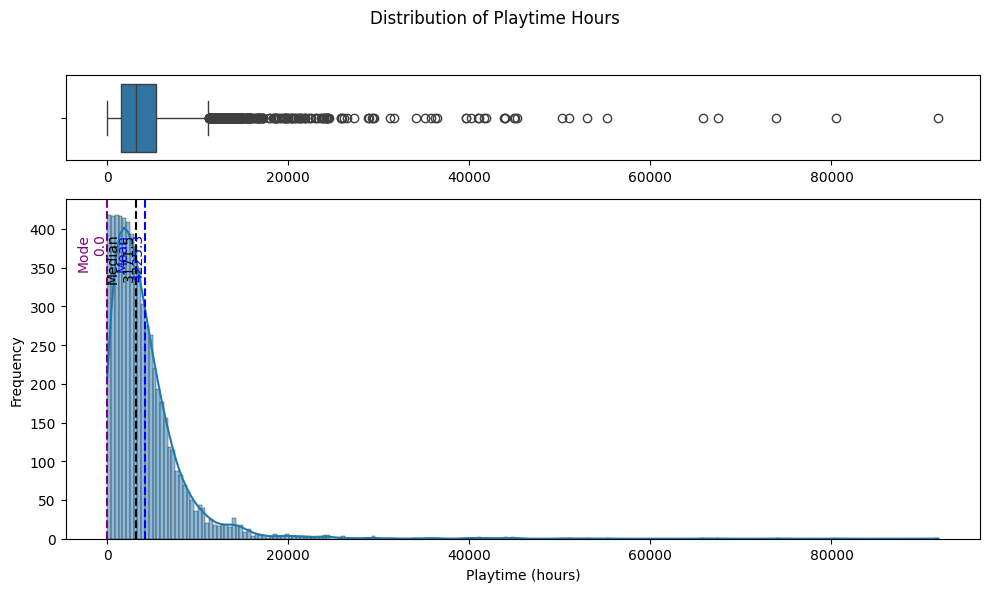

In [12]:
# Filter data
viz_playtime = df_drop_nulls.withColumn('playtime_hours', spark_round(col('game_playtime_forever') / 60))
viz_playtime = viz_playtime.select('playtime_hours')
viz_playtime = viz_playtime.groupBy('playtime_hours').count()
viz_playtime = viz_playtime.toPandas()

# Calculate statistics
mean_val = viz_playtime['playtime_hours'].mean()
q1 = viz_playtime['playtime_hours'].quantile(0.25)
q2 = viz_playtime['playtime_hours'].quantile(0.50)
q3 = viz_playtime['playtime_hours'].quantile(0.75)
mode_val = viz_playtime.loc[viz_playtime['count'].idxmax(), 'playtime_hours']

# Fig configuration
fig, ax = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [1, 4]})

# Box Plot
sns.boxplot(x=viz_playtime['playtime_hours'], ax=ax[0], orient='h')
ax[0].set_xlabel('')

# Histogram
sns.histplot(viz_playtime['playtime_hours'], ax=ax[1], kde=True)
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Playtime (hours)')

# Add statistics
stats = [
    (mean_val, 'Mean', 'blue'),
    #(q1, 'Q1', 'orange'),
    (q2, 'Median', 'black'),
    #(q3, 'Q3', 'red'),
    (mode_val, 'Mode', 'purple')
]

for val, label, color in stats:
    ax[1].axvline(val, color=color, linestyle='--', linewidth=1.5, label=f'{label}: {val:.2f}')
    ax[1].text(val, ax[1].get_ylim()[1]*0.9, f'{label}\n{val:.1f}', color=color, rotation=90, ha='right', va='top')

# Title
plt.suptitle('Distribution of Playtime Hours')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


### Without zeros

In [13]:
# Number of users
players = df_drop_zeros.select('user_steamid').distinct().count()

# Number of games
games = df_drop_zeros.select('game_appid').distinct().count()

# Average playtime per user
avg_playtime_per_user = df_drop_zeros.groupBy('user_steamid').agg(avg('game_playtime_forever').alias('avg_playtime'))
overall_avg_playtime_per_user = avg_playtime_per_user.agg(avg('avg_playtime')).collect()[0]['avg(avg_playtime)']


# Average playtime per game
avg_playtime_per_game = df_drop_zeros.groupBy('game_appid').agg(avg('game_playtime_forever').alias('avg_playtime'))
overall_avg_playtime_per_game = avg_playtime_per_game.agg(avg('avg_playtime')).collect()[0]['avg(avg_playtime)']

# Show results
print(f'Number of players: {players}')
print(f'Number of games: {games}')
print(f'Average playtime per player (in hours): {round(overall_avg_playtime_per_user/60,2)}')
print(f'Average playtime per game (in hours): {round(overall_avg_playtime_per_game/60,2)}')

Number of players: 15673
Number of games: 34161
Average playtime per player (in hours): 158.65
Average playtime per game (in hours): 6.97


#### Players

In [14]:
viz_playtime = df_drop_zeros.select('game_playtime_forever', 'user_steamid')
viz_playtime = viz_playtime.groupBy('user_steamid').agg(avg('game_playtime_forever').alias('avg_playtime'))
viz_playtime = viz_playtime.withColumn('playtime_hours', spark_round(col('avg_playtime') / 60))
viz_playtime = viz_playtime.toPandas()
viz_playtime.describe()

,avg_playtime,playtime_hours
count,1.567300e+04,15673.000000
mean,9.519064e+03,158.653225
std,2.540651e+04,423.443854
min,1.000000e+00,0.000000
25%,1.584000e+03,26.000000
50%,3.500392e+03,58.000000
75%,8.307963e+03,138.000000
max,1.074474e+06,17908.000000


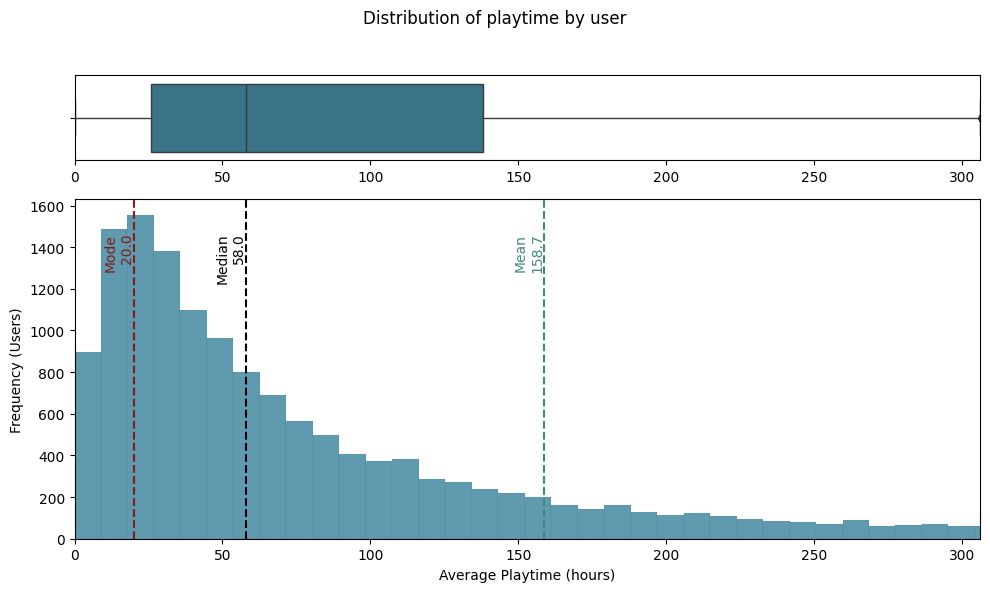

In [15]:
# Filter data
viz_playtime = df_drop_zeros.select('game_playtime_forever', 'user_steamid')
viz_playtime = viz_playtime.groupBy('user_steamid').agg(avg('game_playtime_forever').alias('avg_playtime'))
viz_playtime = viz_playtime.withColumn('playtime_hours', spark_round(col('avg_playtime') / 60))
viz_playtime = viz_playtime.toPandas()

# Calculate statistics
mean_val = viz_playtime['playtime_hours'].mean()
q1 = viz_playtime['playtime_hours'].quantile(0.25)
q2 = viz_playtime['playtime_hours'].quantile(0.50)
q3 = viz_playtime['playtime_hours'].quantile(0.75)
mode_val = viz_playtime['playtime_hours'].round().mode()[0]

# Plotting range based on IQR
iqr = q3 - q1
lower_bound = 0
upper_bound = q3 + 1.5 * iqr

# Fig configuration
fig, ax = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [1, 4]})

# Main Color
main_color = '#2B7995'

# Box Plot
sns.boxplot(x=viz_playtime['playtime_hours'], ax=ax[0], orient='h', color=main_color)
ax[0].set_xlabel('')
ax[0].set_xlim(lower_bound, upper_bound)

# Histogram
sns.histplot(viz_playtime['playtime_hours'], ax=ax[1], kde=False, color=main_color)
ax[1].set_ylabel('Frequency (Users)')
ax[1].set_xlabel('Average Playtime (hours)')
ax[1].set_xlim(lower_bound, upper_bound)

# Add statistics
stats = [
    (mean_val, 'Mean', '#3f887B'),
    #(q1, 'Q1', 'orange'),
    (q2, 'Median', 'black'),
    #(q3, 'Q3', 'red'),
    (mode_val, 'Mode', '#821B1C')
]

for val, label, color in stats:
    ax[1].axvline(val, color=color, linestyle='--', linewidth=1.5, label=f'{label}: {val:.2f}')
    ax[1].text(val, ax[1].get_ylim()[1]*0.9, f'{label}\n{val:.1f}', color=color, rotation=90, ha='right', va='top')

# Title
plt.suptitle('Distribution of playtime by user')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

#### Games

In [16]:
viz_playtime = df_drop_zeros.select('game_playtime_forever', 'game_appid')
viz_playtime = viz_playtime.groupBy('game_appid').agg(avg('game_playtime_forever').alias('avg_playtime'))
viz_playtime = viz_playtime.withColumn('playtime_hours', spark_round(col('avg_playtime') / 60))
viz_playtime = viz_playtime.toPandas()
viz_playtime.describe()

,game_appid,avg_playtime,playtime_hours
count,3.416100e+04,34161.000000,34161.000000
mean,1.231111e+06,418.396425,6.956354
std,9.767525e+05,4607.584507,76.797085
min,1.000000e+01,0.000000,0.000000
25%,4.946000e+05,6.617647,0.000000
50%,8.363000e+05,86.861111,1.000000
75%,1.767220e+06,218.304348,4.000000
max,4.813200e+06,474962.000000,7916.000000


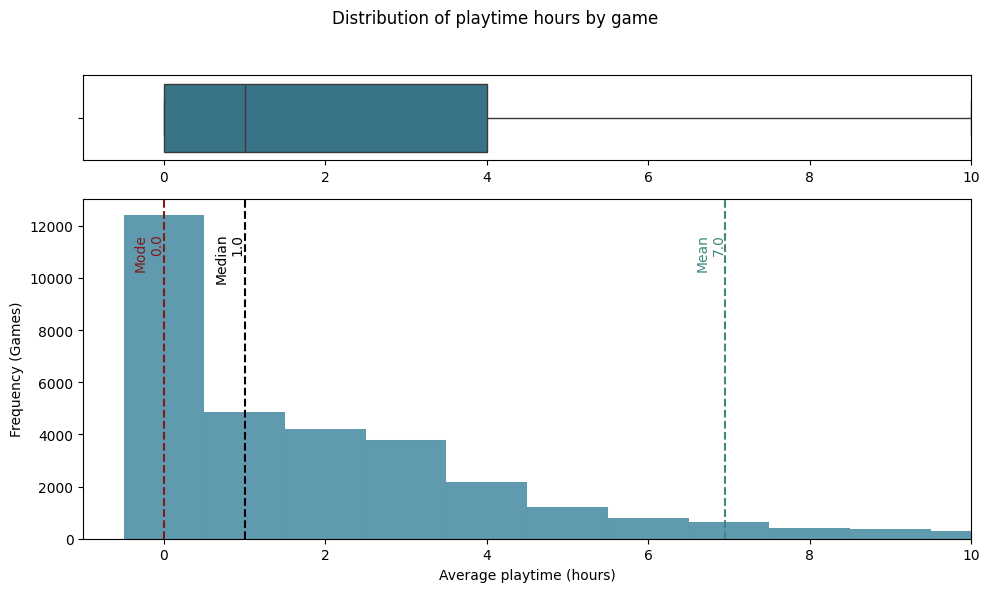

In [17]:
# Filter data
viz_playtime = df_drop_zeros.select('game_playtime_forever', 'game_appid')
viz_playtime = viz_playtime.groupBy('game_appid').agg(avg('game_playtime_forever').alias('avg_playtime'))
viz_playtime = viz_playtime.withColumn('playtime_hours', spark_round(col('avg_playtime') / 60))
viz_playtime = viz_playtime.toPandas()

# Calculate statistics
mean_val = viz_playtime['playtime_hours'].mean()
q1 = viz_playtime['playtime_hours'].quantile(0.25)
q2 = viz_playtime['playtime_hours'].quantile(0.50)
q3 = viz_playtime['playtime_hours'].quantile(0.75)
mode_val = viz_playtime['playtime_hours'].round().mode()[0]

# Plotting range based on IQR
iqr = q3 - q1
lower_bound = -1
upper_bound = q3 + 1.5 * iqr

# Fig configuration
fig, ax = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [1, 4]})

# Main Color
main_color = '#2B7995'

# Box Plot
sns.boxplot(x=viz_playtime['playtime_hours'], ax=ax[0], orient='h', color=main_color)
ax[0].set_xlabel('')
ax[0].set_xlim(lower_bound, upper_bound)

# Histogram
sns.histplot(viz_playtime['playtime_hours'], ax=ax[1], kde=False, color=main_color, discrete=True)
ax[1].set_ylabel('Frequency (Games)')
ax[1].set_xlabel('Average playtime (hours)')
ax[1].set_xlim(lower_bound, upper_bound)

# Add statistics
stats = [
    (mean_val, 'Mean', '#3f887B'),
    #(q1, 'Q1', 'orange'),
    (q2, 'Median', 'black'),
    #(q3, 'Q3', 'red'),
    (mode_val, 'Mode', '#821B1C')
]

for val, label, color in stats:
    ax[1].axvline(val, color=color, linestyle='--', linewidth=1.5, label=f'{label}: {val:.2f}')
    ax[1].text(val, ax[1].get_ylim()[1]*0.9, f'{label}\n{val:.1f}', color=color, rotation=90, ha='right', va='top')

# Title
plt.suptitle('Distribution of playtime hours by game')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

### Playtime by game

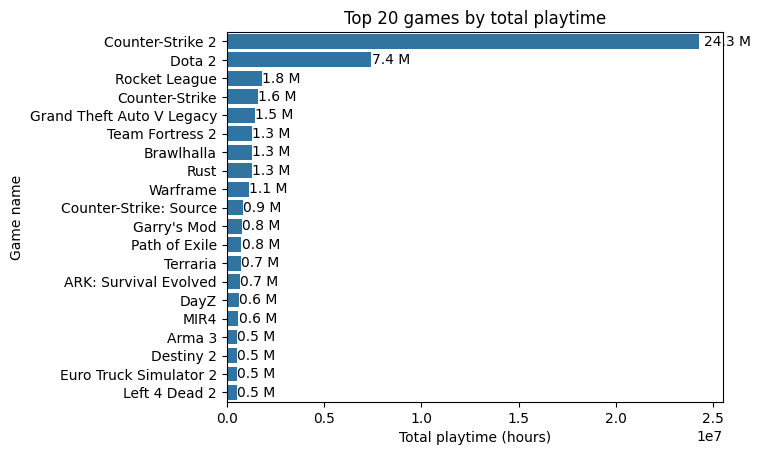

In [18]:
# Playtime by game
playtime_by_game = df_drop_zeros.groupBy('game_name').agg(spark_round(sum(col('game_playtime_forever')) / 60).alias('total_playtime')).orderBy('total_playtime', ascending=False)
playtime_by_game = playtime_by_game.toPandas()

# Bar chart
sns.barplot(x='total_playtime', y='game_name', data=playtime_by_game.head(20))
plt.title('Top 20 games by total playtime')
plt.xlabel('Total playtime (hours)')
plt.ylabel('Game name')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    label = f'{width / 1_000_000:.1f} M'  
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()



### Players by game

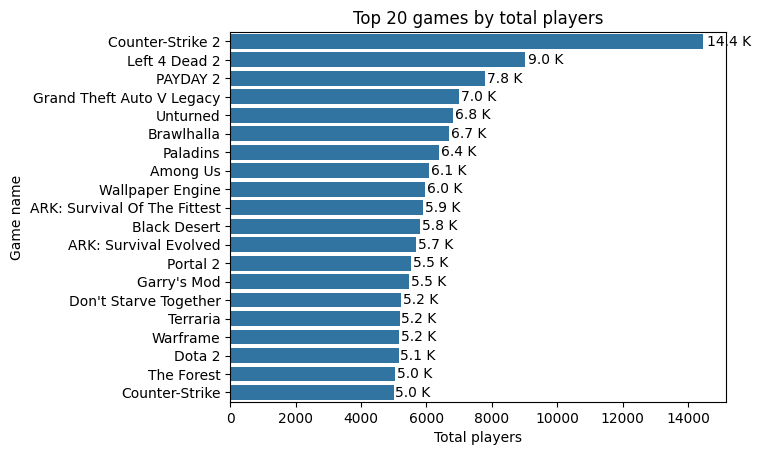

In [19]:
# Playtime by game
players_by_game = df_drop_zeros.groupBy('game_name').agg(spark_round(count(col('user_steamid'))).alias('total_players')).orderBy('total_players', ascending=False)
players_by_game = players_by_game.toPandas()

# Bar chart
sns.barplot(x='total_players', y='game_name', data=players_by_game.head(20))
plt.title('Top 20 games by total players')
plt.xlabel('Total players')
plt.ylabel('Game name')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    label = f'{width / 1_000:.1f} K'  
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()

### Bayesian Playtime

With the bayesian playtime, if some users only played a few games, their average playtime might be unreliable. This formula helps by pulling their average towards the global mean, depending on how much data (number of games) they have.

$$
q = \frac{\sum_{i=1}^{n} r_i + C \times m}{C + n}
$$

Where:

- $r$ is the playtime of each game
- $n$ is the total number of observed values ofr the item
- $C$ is the average number of players across all games
- $m$ is the overall average playtime in the whole set

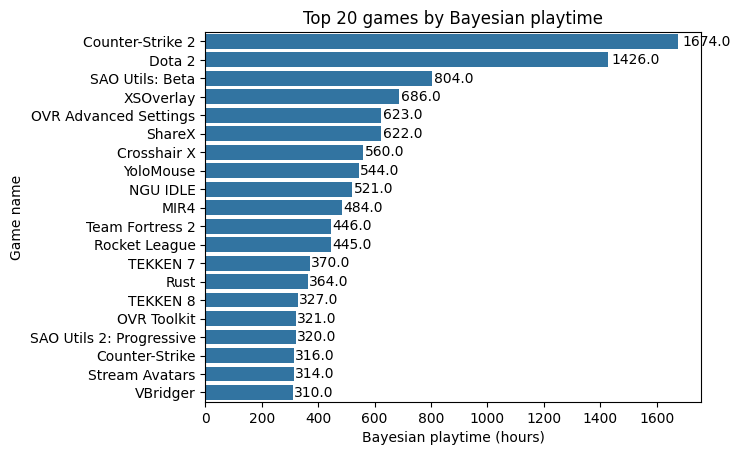

In [20]:
df_bayesian_playtime = df_drop_zeros.groupBy('game_appid').agg(
    sum('game_playtime_forever').alias('total_playtime'), #r
    count('user_steamid').alias('num_players')
)

C = df_bayesian_playtime.agg(avg('num_players')).collect()[0][0]
m = df_drop_zeros.agg(avg('game_playtime_forever')).collect()[0][0]

df_game_names = df_drop_zeros.select("game_appid", "game_name").dropDuplicates(["game_appid"])

df_bayesian_playtime = df_bayesian_playtime.withColumn('bayesian_playtime', (df_bayesian_playtime.total_playtime + C * m) / (C + df_bayesian_playtime.num_players))
df_bayesian_playtime = df_bayesian_playtime.join(df_game_names, on='game_appid', how='left').select('game_appid', 'game_name', 'total_playtime', 'num_players', 'bayesian_playtime')
df_bayesian_playtime = df_bayesian_playtime.groupBy('game_name').agg(spark_round(sum(col('bayesian_playtime')) / 60).alias('total_bayesian_playtime')).orderBy('total_bayesian_playtime', ascending=False)

df_bayesian_playtime = df_bayesian_playtime.toPandas()

# Bar chart
sns.barplot(x='total_bayesian_playtime', y='game_name', data=df_bayesian_playtime.head(20))
plt.title('Top 20 games by Bayesian playtime')
plt.xlabel('Bayesian playtime (hours)')
plt.ylabel('Game name')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    label = f'{width}'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()

## Defining a ranking for games and comparing

Assigning a rating from 1 to 5 to each row based on how much a user has played each game, where:

- 5 = most played game(s) per user
- 1 = least played game(s) per user

In [21]:
window_spec = Window.partitionBy('user_steamid').orderBy(col('game_playtime_forever').desc())
df_rating = df_drop_zeros.withColumn("raw_tile", ntile(5).over(window_spec))
df_rating = df_rating.withColumn("rating", expr("6 - raw_tile"))

### Analysing data based on ranking

#### Rating Distribution

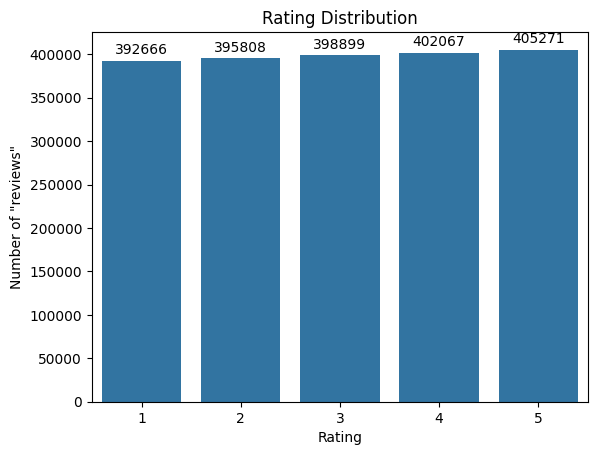

In [22]:
# Filter data
viz_rating = df_rating.groupBy('rating').count()
viz_rating = viz_rating.toPandas()

sns.barplot(x='rating', y='count', data=viz_rating)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of "reviews"')

# Annotate bars with values
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    label = f'{height:.0f}'
    ax.text(x, height + (height * 0.01), label, ha='center', va='bottom', fontsize=10)

plt.show()

#### Top Games by Average Rating

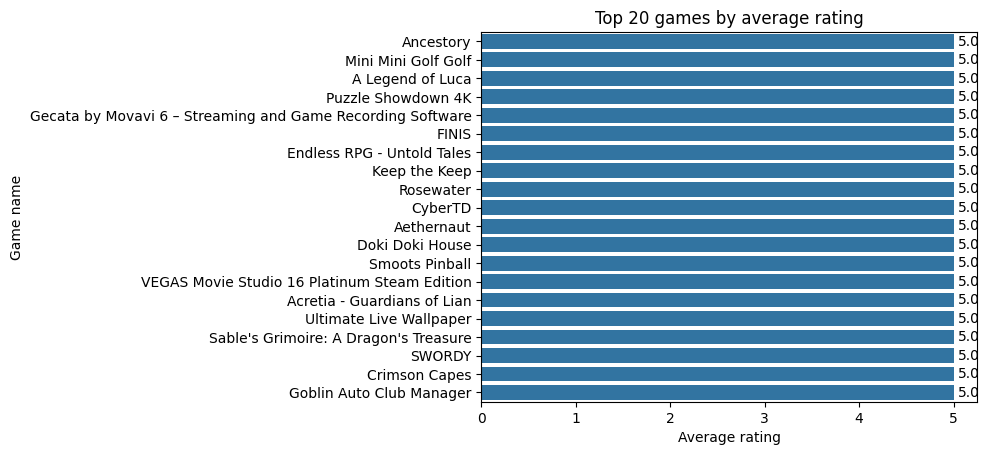

In [23]:
df_game_names = df_rating.select("game_appid", "game_name").dropDuplicates(["game_appid"])

average_rating = df_rating.groupBy('game_appid').agg(
    avg('rating').alias('average_rating'),
    count('user_steamid').alias('num_players')
)
average_rating = average_rating.join(df_game_names, on='game_appid', how='left')\
                               .select('game_name', 'average_rating', 'num_players')\
                               .orderBy('average_rating', ascending=False)

average_rating = average_rating.toPandas()

# Bar chart
sns.barplot(x='average_rating', y='game_name', data=average_rating.head(20))
plt.title('Top 20 games by average rating')
plt.xlabel('Average rating')
plt.ylabel('Game name')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    label = f'{width}'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()

#### Top Games by Bayesian Average Rating

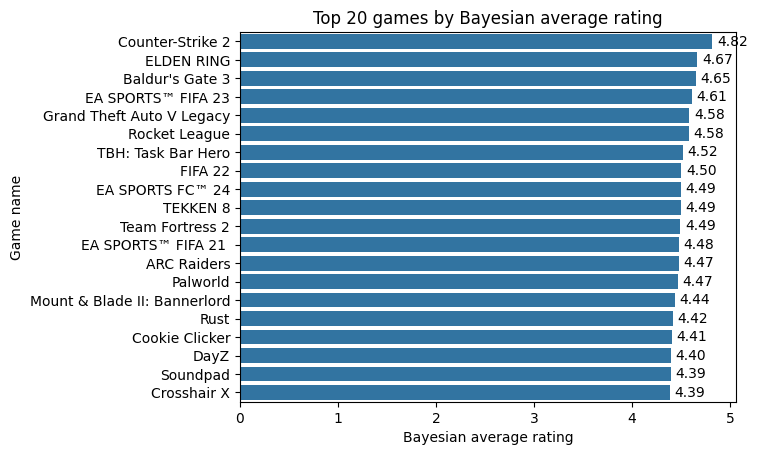

In [24]:
df_game_names = df_rating.select("game_appid", "game_name").dropDuplicates(["game_appid"])

bayesian_average_rating = df_rating.groupBy('game_appid').agg(
    sum('rating').alias('total_rating'),
    avg('rating').alias('avg_rating'),
    count('user_steamid').alias('num_players')
)

C = bayesian_average_rating.agg(avg('num_players')).collect()[0][0]
m = df_rating.agg(avg('rating')).collect()[0][0]

bayesian_average_rating = bayesian_average_rating.withColumn('bayesian_rating', (bayesian_average_rating.total_rating + C * m) / (C + bayesian_average_rating.num_players))
bayesian_average_rating = bayesian_average_rating.join(df_game_names, on='game_appid', how='left')\
                                                 .select('game_appid', 'game_name', 'avg_rating', 'num_players', 'bayesian_rating')
bayesian_average_rating = bayesian_average_rating.select('game_name', 'bayesian_rating')\
                                                 .orderBy('bayesian_rating', ascending=False)
bayesian_average_rating = bayesian_average_rating.toPandas()

# Bar chart
sns.barplot(x='bayesian_rating', y='game_name', data=bayesian_average_rating.head(20))
plt.title('Top 20 games by Bayesian average rating')
plt.xlabel('Bayesian average rating')
plt.ylabel('Game name')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    label = f'{width:.2f}'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()


## Genre and tags

### Exploding genre and tags

In [25]:
# Filter unique games
df_game_genres = df_drop_zeros.select('game_appid', 'game_detail_genres').dropDuplicates()
df_game_tags = df_drop_zeros.select('game_appid', 'game_detail_tags').dropDuplicates()

In [26]:
# Explode genre and tags
df_exploded_genres = df_game_genres.withColumn("game_detail_genres", explode("game_detail_genres"))
df_exploded_tags = df_game_tags.withColumn("game_detail_tags", explode("game_detail_tags"))

In [27]:
df_exploded_genres.printSchema()
df_exploded_tags.printSchema()

root
 |-- game_appid: long (nullable = true)
 |-- game_detail_genres: string (nullable = true)

root
 |-- game_appid: long (nullable = true)
 |-- game_detail_tags: string (nullable = true)



In [28]:
df_info(df_exploded_genres)
df_info(df_exploded_tags)

+------------------+------+-----+------+
|column_name       |filled|nulls|unique|
+------------------+------+-----+------+
|game_appid        |96826 |0    |34161 |
|game_detail_genres|96826 |0    |24    |
+------------------+------+-----+------+

+----------------+------+-----+------+
|column_name     |filled|nulls|unique|
+----------------+------+-----+------+
|game_appid      |486696|0    |34161 |
|game_detail_tags|486696|0    |432   |
+----------------+------+-----+------+



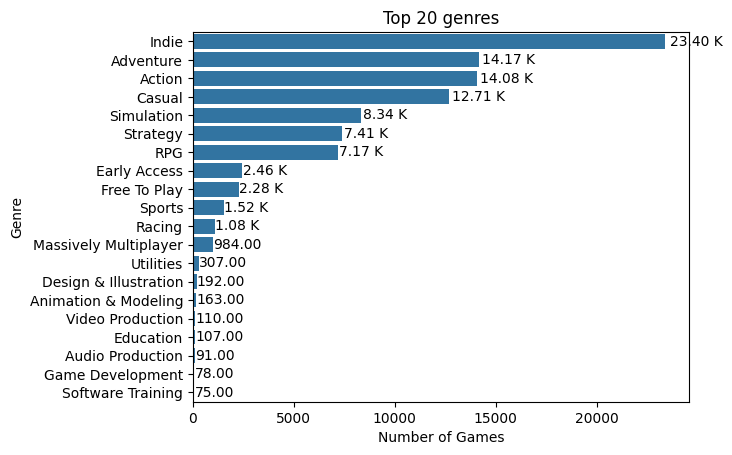

In [29]:
viz_genres = df_exploded_genres.groupBy('game_detail_genres').count()
viz_genres = viz_genres.orderBy('count', ascending=False)
viz_genres = viz_genres.toPandas()

# Bar chart
sns.barplot(x='count', y='game_detail_genres', data=viz_genres.head(20))
plt.title('Top 20 genres')
plt.xlabel('Number of Games')
plt.ylabel('Genre')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    if width < 1_000:
        label = f'{width:.2f}'
    else:
        label = f'{width/1_000:.2f} K'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()



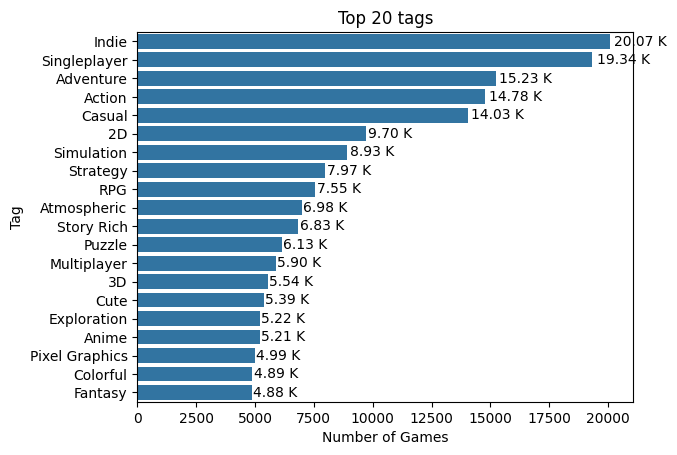

In [30]:
viz_tags = df_exploded_tags.groupBy('game_detail_tags').count()
viz_tags = viz_tags.orderBy('count', ascending=False)
viz_tags = viz_tags.toPandas()

# Bar chart
sns.barplot(x='count', y='game_detail_tags', data=viz_tags.head(20))
plt.title('Top 20 tags')
plt.xlabel('Number of Games')
plt.ylabel('Tag')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    if width < 1_000:
        label = f'{width:.2f}'
    else:
        label = f'{width/1_000:.2f} K'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()

In [31]:
# Filter unique games with playtime_forever and user_steamid count
df_game_playtime = df_drop_zeros.select('game_appid', 'game_playtime_forever')
df_game_playtime = df_game_playtime.groupBy('game_appid').agg(sum('game_playtime_forever').alias('game_playtime_forever'))
df_game_playtime = df_game_playtime.withColumn('playtime_hours', spark_round(col('game_playtime_forever') / 60))

df_game_users = df_drop_zeros.select('game_appid', 'user_steamid')
df_game_users = df_game_users.groupBy('game_appid').agg(countDistinct('user_steamid').alias('game_users'))

In [32]:
# Join with exploded genres and tags

df_exploded_genres_playtime = df_exploded_genres.join(df_game_playtime, on=['game_appid'], how='left')
df_exploded_genres_users = df_exploded_genres.join(df_game_users, on=['game_appid'], how='left')

df_exploded_tags_playtime = df_exploded_tags.join(df_game_playtime, on=['game_appid'], how='left')
df_exploded_tags_users = df_exploded_tags.join(df_game_users, on=['game_appid'], how='left')


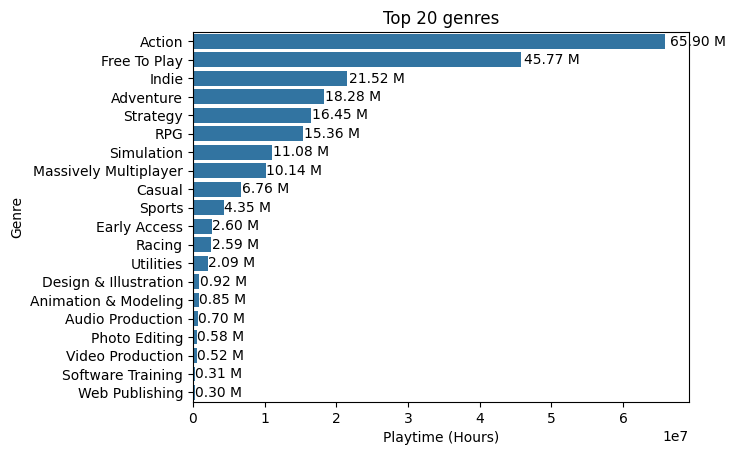

In [33]:
viz_genres_playtime = df_exploded_genres_playtime.groupBy('game_detail_genres').agg(sum('playtime_hours').alias('playtime_hours'))
viz_genres_playtime = viz_genres_playtime.orderBy('playtime_hours', ascending=False)
viz_genres_playtime = viz_genres_playtime.toPandas()

# Bar chart
sns.barplot(x='playtime_hours', y='game_detail_genres', data=viz_genres_playtime.head(20))
plt.title('Top 20 genres')
plt.xlabel('Playtime (Hours)')
plt.ylabel('Genre')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    if width < 1_000:
        label = f'{width:.2f}'
    else:
        label = f'{width/1_000_000:.2f} M'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()


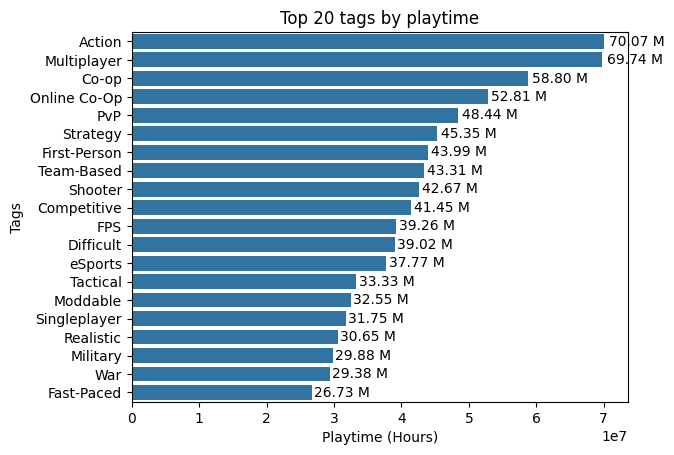

In [34]:
viz_tags_playtime = df_exploded_tags_playtime.groupBy('game_detail_tags').agg(sum('playtime_hours').alias('playtime_hours'))
viz_tags_playtime = viz_tags_playtime.orderBy('playtime_hours', ascending=False)
viz_tags_playtime = viz_tags_playtime.toPandas()

# Bar chart
sns.barplot(x='playtime_hours', y='game_detail_tags', data=viz_tags_playtime.head(20))
plt.title('Top 20 tags by playtime')
plt.xlabel('Playtime (Hours)')
plt.ylabel('Tags')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    if width < 1_000:
        label = f'{width:.2f}'
    else:
        label = f'{width/1_000_000:.2f} M'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()

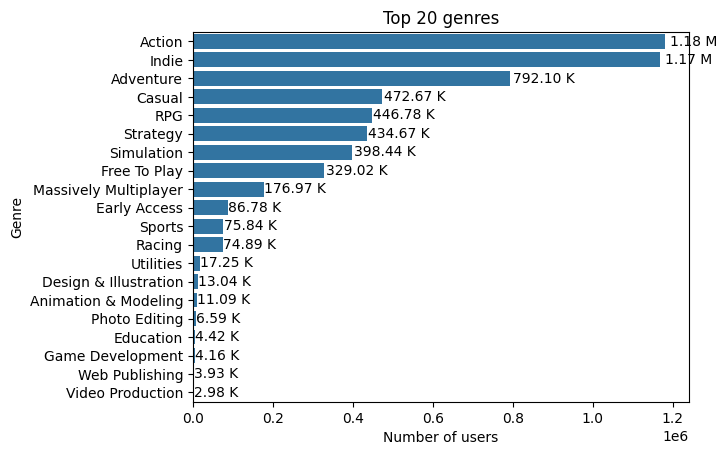

In [35]:
viz_genres_users = df_exploded_genres_users.groupBy('game_detail_genres').agg(sum('game_users').alias('game_users'))
viz_genres_users = viz_genres_users.orderBy('game_users', ascending=False)
viz_genres_users = viz_genres_users.toPandas()

# Bar chart
sns.barplot(x='game_users', y='game_detail_genres', data=viz_genres_users.head(20))
plt.title('Top 20 genres')
plt.xlabel('Number of users')
plt.ylabel('Genre')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    if width < 1_000:
        label = f'{width:.2f}'
    elif width < 1_000_000:
        label = f'{width/1_000:.2f} K'
    else:
        label = f'{width/1_000_000:.2f} M'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()

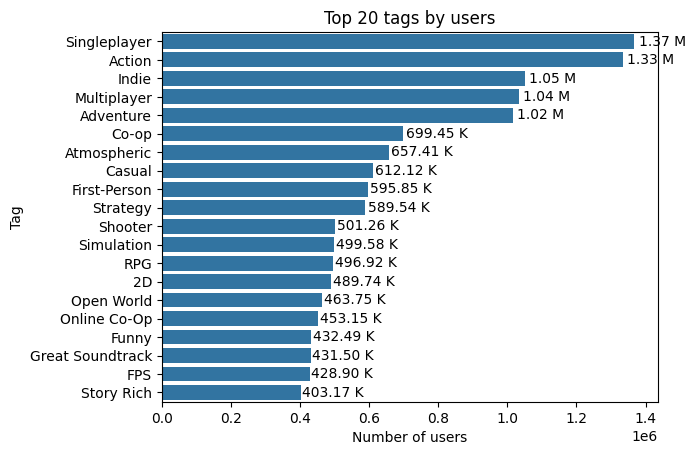

In [36]:
viz_tags_users = df_exploded_tags_users.groupBy('game_detail_tags').agg(sum('game_users').alias('game_users'))
viz_tags_users = viz_tags_users.orderBy('game_users', ascending=False)
viz_tags_users = viz_tags_users.toPandas()

# Bar chart
sns.barplot(x='game_users', y='game_detail_tags', data=viz_tags_users.head(20))
plt.title('Top 20 tags by users')
plt.xlabel('Number of users')
plt.ylabel('Tag')

# Get current Axes
ax = plt.gca()

# Add text labels formatted as millions
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    if width < 1_000:
        label = f'{width:.2f}'
    elif width < 1_000_000:
        label = f'{width/1_000:.2f} K'
    else:
        label = f'{width/1_000_000:.2f} M'
    ax.text(width + (width * 0.01), y, label, va='center')

plt.show()

## Term Frequency–Inverse Document Frequency vectors (TF-IDF)

In [37]:
df_genres = df_exploded_genres.withColumn(
    'game_detail_genres',
    concat(lit('genre_'), df_exploded_genres['game_detail_genres'])
).withColumnRenamed('game_detail_genres', 'feature')

df_tags = df_exploded_tags.withColumn(
    'game_detail_tags',
    concat(lit('tag_'), df_exploded_tags['game_detail_tags'])
).withColumnRenamed('game_detail_tags', 'feature')

In [38]:
df_multi_hot = df_genres.union(df_tags)

In [39]:
# df_multi_hot = df_multi_hot.withColumn('value',lit(1))
# df_multi_hot = df_multi_hot.groupBy('game_appid').pivot('feature').sum('value').fillna(0)

In [40]:
# HashingTF → sparse vector for tags
hashing_tf= HashingTF(inputCol='feature', outputCol='rawFeatures', numFeatures=100)
tf= hashing_tf.transform(df_multi_hot.groupBy('game_appid').agg(collect_list('feature').alias('feature')))

In [41]:
tf.show(5)

+----------+--------------------+--------------------+
|game_appid|             feature|         rawFeatures|
+----------+--------------------+--------------------+
|        50|[genre_Action, ta...|(100,[0,10,19,24,...|
|       130|[genre_Action, ta...|(100,[0,10,19,28,...|
|       570|[genre_Action, ge...|(100,[5,19,22,24,...|
|       730|[genre_Action, ge...|(100,[5,19,22,24,...|
|      1200|[genre_Action, ta...|(100,[10,18,19,22...|
+----------+--------------------+--------------------+
only showing top 5 rows


In [42]:
# IDF for weighting
idf = IDF(inputCol="rawFeatures", outputCol="features")
idf_model = idf.fit(tf)
tfidf = idf_model.transform(tf)

In [43]:
tfidf.show(5)

+----------+--------------------+--------------------+--------------------+
|game_appid|             feature|         rawFeatures|            features|
+----------+--------------------+--------------------+--------------------+
|        50|[genre_Action, ta...|(100,[0,10,19,24,...|(100,[0,10,19,24,...|
|       130|[genre_Action, ta...|(100,[0,10,19,28,...|(100,[0,10,19,28,...|
|       570|[genre_Action, ge...|(100,[5,19,22,24,...|(100,[5,19,22,24,...|
|       730|[genre_Action, ge...|(100,[5,19,22,24,...|(100,[5,19,22,24,...|
|      1200|[genre_Action, ta...|(100,[10,18,19,22...|(100,[10,18,19,22...|
+----------+--------------------+--------------------+--------------------+
only showing top 5 rows


## Joining with original df wihtout nulls

In [44]:
df_clean = df_rating.drop('game_detail_genres', 'game_detail_tags')

### Replacing nulls

In [45]:
df_clean = df_clean.fillna({'user_loccountrycode': 'Unknown',
                            'game_detail_developer': 'Unknown',
                            'game_detail_publisher': 'Unknown'})

df_clean = df_clean.withColumn(
    "game_name",
    when(col("game_name").isNull(), concat(lit("Unknown_"), col("game_appid")))
    .otherwise(col("game_name"))
)

In [46]:
df_info(df_clean)

+------------------------+-------+-----+------+
|column_name             |filled |nulls|unique|
+------------------------+-------+-----+------+
|game_appid              |1994711|0    |34161 |
|user_personaname        |1994711|0    |15344 |
|user_loccountrycode     |1994711|0    |211   |
|game_detail_release_date|1994711|0    |5585  |
|raw_tile                |1994711|0    |5     |
|game_playtime_forever   |1994711|0    |49041 |
|game_detail_rating      |1994711|0    |18    |
|user_steamid            |1994711|0    |15673 |
|game_detail_developer   |1994711|0    |20377 |
|game_name               |1994711|0    |34097 |
|game_detail_publisher   |1994711|0    |15572 |
|game_img_icon_url       |1994711|0    |33655 |
|rating                  |1994711|0    |5     |
+------------------------+-------+-----+------+



### Transforming string to data

In [47]:
df_clean = df_clean.withColumn('game_detail_release_date', to_date('game_detail_release_date', 'yyyy-MM-dd'))

In [48]:
# ==========================================
# ШАГ 1: Преобразование строкового рейтинга Steam в числовой
# ==========================================
from pyspark.sql.functions import when, col

# Создаем выражение для маппинга строковых рейтингов в числа (от 0.5 до 5.0)
steam_rating_expr = (
    when(col("game_detail_rating") == "Overwhelmingly Positive", 5.0)
    .when(col("game_detail_rating") == "Very Positive", 4.5)
    .when(col("game_detail_rating") == "Mostly Positive", 4.0)
    .when(col("game_detail_rating") == "Positive", 3.5)
    .when(col("game_detail_rating") == "Mixed", 3.0)
    .when(col("game_detail_rating") == "Mostly Negative", 2.0)
    .when(col("game_detail_rating") == "Negative", 1.5)
    .when(col("game_detail_rating") == "Very Negative", 1.0)
    .when(col("game_detail_rating") == "Overwhelmingly Negative", 0.5)
    .otherwise(3.0) # Если рейтинг неизвестен (null), ставим нейтральный 3.0
)

# Применяем маппинг к нашему очищенному датафрейму
df_clean = df_clean.withColumn("steam_rating", steam_rating_expr)

# Проверяем, что колонка добавилась и выглядит корректно
df_clean.select("game_name", "game_detail_rating", "steam_rating").show(10, truncate=False)

+---------------------------------------------+-----------------------+------------+
|game_name                                    |game_detail_rating     |steam_rating|
+---------------------------------------------+-----------------------+------------+
|Counter-Strike                               |Overwhelmingly Positive|5.0         |
|Counter-Strike: Condition Zero               |Very Positive          |4.5         |
|Counter-Strike: Condition Zero Deleted Scenes|Very Positive          |4.5         |
|Counter-Strike: Source                       |Overwhelmingly Positive|5.0         |
|Dota 2                                       |Mixed                  |3.0         |
|Counter-Strike 2                             |Very Positive          |4.5         |
|PAYDAY 2                                     |Very Positive          |4.5         |
|Heroes & Generals                            |Mostly Positive        |4.0         |
|Rocket League                                |Mixed             

In [49]:

#  Создание комбинированного рейтинга
# alpha = 0.7 означает: 70% важности времени игры пользователя + 30% важности глобального рейтинга Steam
alpha = 0.7 

df_clean = df_clean.withColumn(
    "combined_rating", 
    (col("rating") * alpha) + (col("steam_rating") * (1 - alpha))
)

# Проверяем результат
df_clean.select("game_name", "rating", "steam_rating", "combined_rating").show(10, truncate=False)

+------------------------------+------+------------+---------------+
|game_name                     |rating|steam_rating|combined_rating|
+------------------------------+------+------------+---------------+
|Counter-Strike: Source        |5     |5.0         |5.0            |
|Counter-Strike 2              |5     |4.5         |4.85           |
|Counter-Strike                |5     |5.0         |5.0            |
|Hunt: Showdown 1896           |5     |3.0         |4.4            |
|Counter-Strike: Condition Zero|5     |4.5         |4.85           |
|Palworld                      |5     |5.0         |5.0            |
|Hentai Girl Fantasy           |5     |4.5         |4.85           |
|Hentai Girl                   |5     |4.5         |4.85           |
|Hentai Girl Hime              |5     |4.5         |4.85           |
|Hentai Girl Linda             |5     |4.5         |4.85           |
+------------------------------+------+------------+---------------+
only showing top 10 rows


In [50]:
df_clean.printSchema()


root
 |-- user_steamid: string (nullable = true)
 |-- user_personaname: string (nullable = true)
 |-- user_loccountrycode: string (nullable = false)
 |-- game_appid: long (nullable = true)
 |-- game_name: string (nullable = true)
 |-- game_playtime_forever: double (nullable = true)
 |-- game_detail_release_date: date (nullable = true)
 |-- game_detail_developer: string (nullable = false)
 |-- game_detail_publisher: string (nullable = false)
 |-- game_detail_rating: string (nullable = true)
 |-- game_img_icon_url: string (nullable = true)
 |-- raw_tile: integer (nullable = false)
 |-- rating: integer (nullable = false)
 |-- steam_rating: double (nullable = false)
 |-- combined_rating: double (nullable = false)



### Final join

In [51]:
df_joined = df_clean.join(
    tfidf,
    on='game_appid',
    how='left'
)

In [52]:
df_joined.show(5)

+----------+-----------------+--------------------+-------------------+----------------+---------------------+------------------------+---------------------+---------------------+------------------+--------------------+--------+------+------------+---------------+--------------------+--------------------+--------------------+
|game_appid|     user_steamid|    user_personaname|user_loccountrycode|       game_name|game_playtime_forever|game_detail_release_date|game_detail_developer|game_detail_publisher|game_detail_rating|   game_img_icon_url|raw_tile|rating|steam_rating|combined_rating|             feature|         rawFeatures|            features|
+----------+-----------------+--------------------+-------------------+----------------+---------------------+------------------------+---------------------+---------------------+------------------+--------------------+--------+------+------------+---------------+--------------------+--------------------+--------------------+
|       730|7656

In [53]:
df_joined.printSchema()

root
 |-- game_appid: long (nullable = true)
 |-- user_steamid: string (nullable = true)
 |-- user_personaname: string (nullable = true)
 |-- user_loccountrycode: string (nullable = false)
 |-- game_name: string (nullable = true)
 |-- game_playtime_forever: double (nullable = true)
 |-- game_detail_release_date: date (nullable = true)
 |-- game_detail_developer: string (nullable = false)
 |-- game_detail_publisher: string (nullable = false)
 |-- game_detail_rating: string (nullable = true)
 |-- game_img_icon_url: string (nullable = true)
 |-- raw_tile: integer (nullable = false)
 |-- rating: integer (nullable = false)
 |-- steam_rating: double (nullable = false)
 |-- combined_rating: double (nullable = false)
 |-- feature: array (nullable = true)
 |    |-- element: string (containsNull = false)
 |-- rawFeatures: vector (nullable = true)
 |-- features: vector (nullable = true)



In [54]:
df_joined_select = df_joined.select('user_steamid', 'game_appid')
df_info(df_joined_select)

+------------+-------+-----+------+
|column_name |filled |nulls|unique|
+------------+-------+-----+------+
|game_appid  |1994711|0    |34161 |
|user_steamid|1994711|0    |15673 |
+------------+-------+-----+------+



In [55]:
df_joined = df_joined.withColumn(
    "game_img_url",
    concat(
        lit("http://media.steampowered.com/steamcommunity/public/images/apps/"),
        col("game_appid").cast("string"),
        lit("/"),
        col("game_img_icon_url"),
        lit(".jpg")
    )
)

# Save results

In [59]:
import datetime
import os

# Генерируем имя папки с текущим временем
now = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
output_path = f"db/final_dataset_{now}"  # Обратите внимание: без .parquet в конце, это будет папка

print(f"💾 Начинаем сохранение в папку: {output_path}")

# Сохраняем БЕЗ coalesce(1). Spark сам оптимально разобьет данные на части.
df_joined.write.mode("overwrite").parquet(output_path)

print(f"✅ Успешно сохранено!")
print(f"📂 Путь: {os.path.abspath(output_path)}")

# Быстрая проверка: читаем обратно и показываем схему
print("\n📖 Проверяем сохраненные данные...")
df_check = spark.read.parquet(output_path)
print(f"Количество строк: {df_check.count()}")
df_check.printSchema()

💾 Начинаем сохранение в папку: db/final_dataset_2026-06-18_10-06-27
✅ Успешно сохранено!
📂 Путь: d:\steam_recommender_system\3. data_analysis\db\final_dataset_2026-06-18_10-06-27

📖 Проверяем сохраненные данные...
Количество строк: 1994711
root
 |-- game_appid: long (nullable = true)
 |-- user_steamid: string (nullable = true)
 |-- user_personaname: string (nullable = true)
 |-- user_loccountrycode: string (nullable = true)
 |-- game_name: string (nullable = true)
 |-- game_playtime_forever: double (nullable = true)
 |-- game_detail_release_date: date (nullable = true)
 |-- game_detail_developer: string (nullable = true)
 |-- game_detail_publisher: string (nullable = true)
 |-- game_detail_rating: string (nullable = true)
 |-- game_img_icon_url: string (nullable = true)
 |-- raw_tile: integer (nullable = true)
 |-- rating: integer (nullable = true)
 |-- steam_rating: double (nullable = true)
 |-- combined_rating: double (nullable = true)
 |-- feature: array (nullable = true)
 |    |-- 

In [60]:
target_id = '76561198170929798'

# Считаем количество записей именно в df_joined
user_count = df_joined.filter(col("user_steamid") == target_id).count()
print(f"🔍 Найдено записей для пользователя {target_id} в финальной таблице: {user_count}")

🔍 Найдено записей для пользователя 76561198170929798 в финальной таблице: 36


In [61]:
# Замените этот ID на тот, который вы нашли в Шаге 2
valid_user_id ='76561198170929798'

df_joined.filter(col("user_steamid") == valid_user_id) \
    .orderBy(col("game_playtime_forever").desc()) \
         .show(100)

+----------+-----------------+----------------+-------------------+--------------------+---------------------+------------------------+---------------------+---------------------+--------------------+--------------------+--------+------+------------+------------------+--------------------+--------------------+--------------------+--------------------+
|game_appid|     user_steamid|user_personaname|user_loccountrycode|           game_name|game_playtime_forever|game_detail_release_date|game_detail_developer|game_detail_publisher|  game_detail_rating|   game_img_icon_url|raw_tile|rating|steam_rating|   combined_rating|             feature|         rawFeatures|            features|        game_img_url|
+----------+-----------------+----------------+-------------------+--------------------+---------------------+------------------------+---------------------+---------------------+--------------------+--------------------+--------+------+------------+------------------+--------------------+--

In [58]:



# Путь к папке с данными (обратите внимание на экранирование обратных слэшей)
path = r"d:\steam_recommender_system\3. data_analysis\db\final_dataset_2026-06-17_13-19-56"

# Читаем Parquet (папка с файлами-партициями)
df = spark.read.parquet(path)

# Выводим схему (имена столбцов, типы, структуру)
df.printSchema()

# Показываем первые 5 строк (для наглядности)
df.show(5, truncate=False)

# Если нужен только список имён столбцов:
print("Столбцы:", df.columns)

root
 |-- game_appid: long (nullable = true)
 |-- user_steamid: string (nullable = true)
 |-- user_personaname: string (nullable = true)
 |-- user_loccountrycode: string (nullable = true)
 |-- game_name: string (nullable = true)
 |-- game_playtime_forever: double (nullable = true)
 |-- game_detail_release_date: date (nullable = true)
 |-- game_detail_developer: string (nullable = true)
 |-- game_detail_publisher: string (nullable = true)
 |-- game_detail_rating: string (nullable = true)
 |-- game_img_icon_url: string (nullable = true)
 |-- raw_tile: integer (nullable = true)
 |-- rating: integer (nullable = true)
 |-- steam_rating: double (nullable = true)
 |-- combined_rating: double (nullable = true)
 |-- feature: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- rawFeatures: vector (nullable = true)
 |-- features: vector (nullable = true)
 |-- game_img_url: string (nullable = true)

+----------+-----------------+--------------------+-------------------+---